# NYC FHVHV Trip Duration Prediction

In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import json, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Device: {DEVICE}  |  PyTorch {torch.__version__}")


Device: mps  |  PyTorch 2.12.0


In [ ]:
# ── 2. Load data ─────────────────────────────────────────────────────

# Adjust this path to wherever you stored the processed parquet files.
DATA_DIR = Path("")
print("Parquet files found:", list(DATA_DIR.glob('*.parquet')))


In [4]:
# ── 3. Column definitions & evaluation helper ─────────────────────────────────
TARGET = "trip_duration_min"

NUMERIC = [
    "trip_miles", "pickup_hour", "pickup_dow", "pickup_month",
    "request_to_pickup_min", "avg_speed_mph",
    "is_airport", "same_borough", "shared_match_flag_bin",
]
CATEGORICAL = ["company", "pu_borough", "do_borough", "pickup_part_of_day"]
FEATS = NUMERIC + CATEGORICAL


def evaluate(y_true, y_pred):
    """Return MAE, RMSE, MAPE, R² as a dict."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)
    r2   = r2_score(y_true, y_pred)
    return {"mae": round(mae, 4), "rmse": round(rmse, 4),
            "mape": round(mape, 4), "r2": round(r2, 6)}


In [5]:
# ── 4. Load data ──────────────────────────────────────────────────────────────
train = pd.read_parquet(DATA_DIR / 'train_2023.parquet')
test  = pd.read_parquet(DATA_DIR / 'test_2023.parquet')
oot   = pd.read_parquet(DATA_DIR / 'oot_2022-12.parquet')

print(f"train {train.shape}  test {test.shape}  oot {oot.shape}")
print(f"Target range: {test[TARGET].min():.1f} – {test[TARGET].max():.1f} min  "
      f"(median {test[TARGET].median():.1f} min)")


train (3996606, 47)  test (999152, 47)  oot (199699, 47)
Target range: 1.0 – 237.0 min  (median 16.1 min)


In [6]:
# ── 5. Shared sklearn preprocessor ───────────────────────────────────────────
def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
        ],
        remainder="drop",
    )


In [7]:
# ── 6. Ridge baseline & HistGradientBoosting ─────────────────────────────────
ridge_pipe = Pipeline([
    ("pre", build_preprocessor()),
    ("ridge", Ridge(alpha=1.0)),
])
ridge_pipe.fit(train[FEATS], train[TARGET])

gbm_pipe = Pipeline([
    ("pre", build_preprocessor()),
    ("gbm", HistGradientBoostingRegressor(
        max_iter=400, learning_rate=0.05, max_leaf_nodes=63,
        min_samples_leaf=20, random_state=RANDOM_SEED,
    )),
])
gbm_pipe.fit(train[FEATS], train[TARGET])

all_metrics = {
    "ridge": {
        "test_2023":   evaluate(test[TARGET].to_numpy(), ridge_pipe.predict(test[FEATS])),
        "oot_2022_12": evaluate(oot[TARGET].to_numpy(),  ridge_pipe.predict(oot[FEATS])),
    },
    "gbm": {
        "test_2023":   evaluate(test[TARGET].to_numpy(), gbm_pipe.predict(test[FEATS])),
        "oot_2022_12": evaluate(oot[TARGET].to_numpy(),  gbm_pipe.predict(oot[FEATS])),
    },
}
print("Ridge  test:", all_metrics['ridge']['test_2023'])
print("GBM    test:", all_metrics['gbm']['test_2023'])


Ridge  test: {'mae': 4.2319, 'rmse': 6.195, 'mape': 32.4292, 'r2': 0.80827}
GBM    test: {'mae': 0.2476, 'rmse': 1.1853, 'mape': 1.1478, 'r2': 0.992981}


In [9]:
# ── 7. PyTorch MLP definition ─────────────────────────────────────────────────
class TripDurationMLP(nn.Module):
    def __init__(self, input_dim: int, hidden=(128, 64, 32), dropout=0.1):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_mlp(model, Xtr, ytr, Xva, yva,
              epochs=30, batch=8192, lr=1e-3, patience=4, device=DEVICE):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best_val, best_state, wait = float('inf'), None, 0
    history = {"train_loss": [], "val_loss": [], "best_epoch": 0}

    Xtr_t = torch.from_numpy(Xtr).to(device)
    ytr_t = torch.from_numpy(ytr).to(device)
    Xva_t = torch.from_numpy(Xva).to(device)
    yva_t = torch.from_numpy(yva).to(device)

    n = len(Xtr_t)
    for epoch in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n, device=device)
        tr_loss = 0.0
        for i in range(0, n, batch):
            idx = perm[i:i+batch]
            opt.zero_grad()
            loss = loss_fn(model(Xtr_t[idx]), ytr_t[idx])
            loss.backward()
            opt.step()
            tr_loss += loss.item() * len(idx)
        tr_loss /= n

        model.eval()
        with torch.no_grad():
            va_loss = loss_fn(model(Xva_t), yva_t).item()

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        print(f"Epoch {epoch:>3}/{epochs}  train={tr_loss:.4f}  val={va_loss:.4f}")

        if va_loss < best_val:
            best_val = va_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            history["best_epoch"] = epoch
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stop at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    model.to('cpu')
    return history


def predict_mlp(model, X, batch=65536, device=DEVICE):
    model.eval()
    model.to(device)
    parts = []
    Xt = torch.from_numpy(X)
    with torch.no_grad():
        for i in range(0, len(X), batch):
            parts.append(model(Xt[i:i+batch].to(device)).cpu().numpy())
    model.to('cpu')
    return np.concatenate(parts)


In [10]:
# ── 8. MLP training ───────────────────────────────────────────────────────────
tr_mlp, va_mlp = train_test_split(train, test_size=0.1, random_state=RANDOM_SEED)

pre = build_preprocessor()
X_tr = pre.fit_transform(tr_mlp[FEATS]).astype(np.float32)
X_va = pre.transform(va_mlp[FEATS]).astype(np.float32)
X_te = pre.transform(test[FEATS]).astype(np.float32)
X_oot = pre.transform(oot[FEATS]).astype(np.float32)

y_scaler = StandardScaler()
y_tr = y_scaler.fit_transform(tr_mlp[[TARGET]].to_numpy()).astype(np.float32).ravel()
y_va = y_scaler.transform(va_mlp[[TARGET]].to_numpy()).astype(np.float32).ravel()

mlp_model = TripDurationMLP(input_dim=X_tr.shape[1])
hist = train_mlp(mlp_model, X_tr, y_tr, X_va, y_va, epochs=30, batch=8192, patience=4)
print(f"\nBest epoch: {hist['best_epoch']}")


Epoch   1/30  train=0.0803  val=0.0079
Epoch   2/30  train=0.0246  val=0.0074
Epoch   3/30  train=0.0192  val=0.0028
Epoch   4/30  train=0.0168  val=0.0023
Epoch   5/30  train=0.0154  val=0.0044
Epoch   6/30  train=0.0146  val=0.0023
Epoch   7/30  train=0.0139  val=0.0013
Epoch   8/30  train=0.0133  val=0.0033
Epoch   9/30  train=0.0129  val=0.0035
Epoch  10/30  train=0.0125  val=0.0028
Epoch  11/30  train=0.0123  val=0.0022
Early stop at epoch 11

Best epoch: 7


In [11]:
# ── 9. Three-way comparison table ────────────────────────────────────────────
def mlp_predict_minutes(X):
    scaled = predict_mlp(mlp_model, X).reshape(-1, 1)
    return y_scaler.inverse_transform(scaled).ravel()

all_metrics["pytorch_mlp"] = {
    "test_2023":   evaluate(test[TARGET].to_numpy(), mlp_predict_minutes(X_te)),
    "oot_2022_12": evaluate(oot[TARGET].to_numpy(),  mlp_predict_minutes(X_oot)),
}

rows = []
for split in ("test_2023", "oot_2022_12"):
    for model_name, m in all_metrics.items():
        rows.append({"split": split, "model": model_name, **m[split]})
cmp = pd.DataFrame(rows)
print(cmp.to_string(index=False))


      split       model    mae   rmse    mape       r2
  test_2023       ridge 4.2319 6.1950 32.4292 0.808270
  test_2023         gbm 0.2476 1.1853  1.1478 0.992981
  test_2023 pytorch_mlp 0.3077 0.5494  2.9425 0.998492
oot_2022_12       ridge 4.3636 6.3100 34.7899 0.798205
oot_2022_12         gbm 0.2639 1.2575  1.2334 0.991986
oot_2022_12 pytorch_mlp 0.3060 0.5809  2.8697 0.998290


---
## 5. Visualisations

1. **Metric bar charts** — MAE, RMSE, R² across all three models on the held-out test set.
2. **Temporal stability** — how each metric changes from `test_2023` to `oot_2022_12`.
3. **MLP learning curve** — training vs validation MSE per epoch.
4. **Residual analysis** — error distributions and actual-vs-predicted plots for all three models.
5. **Feature leakage diagnostic** — algebraic reconstruction of the target from `avg_speed_mph`.

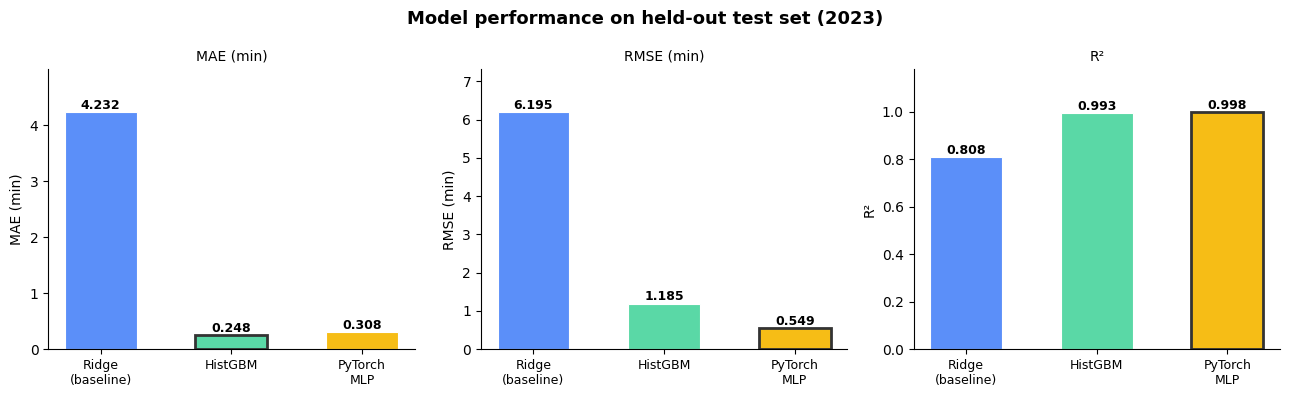

In [12]:
# ── 10. Metric comparison bar charts (test_2023) ──────────────────────────────
MODEL_LABELS = {"ridge": "Ridge\n(baseline)", "gbm": "HistGBM", "pytorch_mlp": "PyTorch\nMLP"}
PALETTE      = {"ridge": "#5b8ff9", "gbm": "#5ad8a6", "pytorch_mlp": "#f6bd16"}
METRICS      = [("mae",  "MAE (min)",  False),
                ("rmse", "RMSE (min)", False),
                ("r2",   "R²",          True)]
models = list(MODEL_LABELS.keys())
x = np.arange(len(models))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Model performance on held-out test set (2023)", fontsize=13, fontweight='bold')

for ax, (metric_key, ylabel, higher_better) in zip(axes, METRICS):
    vals = [all_metrics[m]["test_2023"][metric_key] for m in models]
    bars = ax.bar(x, vals, color=[PALETTE[m] for m in models],
                  edgecolor='white', linewidth=0.8, width=0.55)
    best_idx = int(np.argmax(vals) if higher_better else np.argmin(vals))
    bars[best_idx].set_edgecolor('#333333')
    bars[best_idx].set_linewidth(2)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002 * max(vals),
                f"{v:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in models], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.18)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title(ylabel, fontsize=10)

plt.tight_layout()
plt.savefig('metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


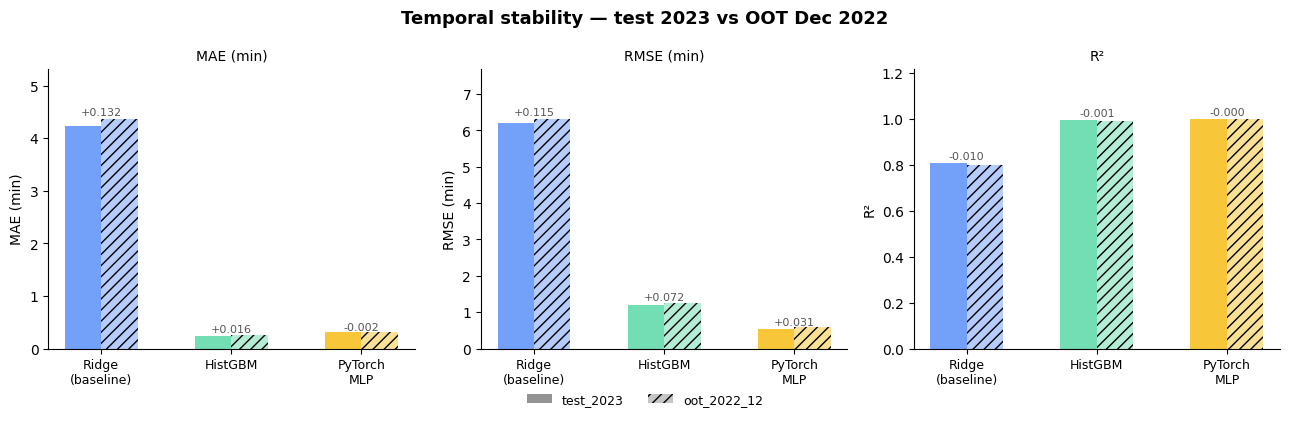

In [13]:
# ── 11. Temporal stability: test_2023 → oot_2022_12 ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle("Temporal stability — test 2023 vs OOT Dec 2022",
             fontsize=13, fontweight='bold')

for ax, (metric_key, ylabel, higher_better) in zip(axes, METRICS):
    width = 0.28
    for i, m in enumerate(models):
        test_val = all_metrics[m]["test_2023"][metric_key]
        oot_val  = all_metrics[m]["oot_2022_12"][metric_key]
        ax.bar(i - width/2, test_val, width=width, color=PALETTE[m], alpha=0.85)
        ax.bar(i + width/2, oot_val,  width=width, color=PALETTE[m], alpha=0.45, hatch='///')
        delta = oot_val - test_val
        sign  = '+' if delta >= 0 else ''
        top   = max(test_val, oot_val)
        ax.text(i, top + 0.01 * top, f"{sign}{delta:.3f}",
                ha='center', va='bottom', fontsize=8, color='#555555')

    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([MODEL_LABELS[m] for m in models], fontsize=9)
    ax.set_ylabel(ylabel)
    vals_all = [all_metrics[m][s][metric_key]
                for m in models for s in ("test_2023", "oot_2022_12")]
    ax.set_ylim(0, max(vals_all) * 1.22)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_title(ylabel, fontsize=10)

from matplotlib.patches import Patch
legend_els = [
    Patch(facecolor='grey', alpha=0.85, label='test_2023'),
    Patch(facecolor='grey', alpha=0.45, hatch='///', label='oot_2022_12'),
]
fig.legend(handles=legend_els, loc='lower center', ncol=2,
           frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig('temporal_stability.png', dpi=150, bbox_inches='tight')
plt.show()


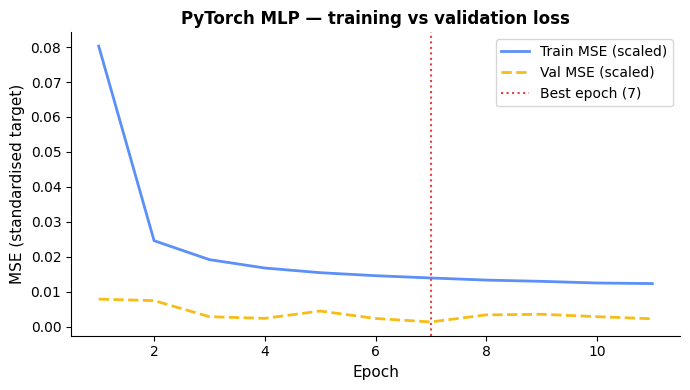

In [14]:
# ── 12. MLP learning curve ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

epochs_axis = range(1, len(hist["train_loss"]) + 1)
ax.plot(epochs_axis, hist["train_loss"], label="Train MSE (scaled)",
        color='#5b8ff9', linewidth=2)
ax.plot(epochs_axis, hist["val_loss"],   label="Val MSE (scaled)",
        color='#f6bd16', linewidth=2, linestyle='--')
ax.axvline(hist["best_epoch"], color='#e84040', linestyle=':',
           linewidth=1.5, label=f"Best epoch ({hist['best_epoch']})")

ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("MSE (standardised target)", fontsize=11)
ax.set_title("PyTorch MLP — training vs validation loss", fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('mlp_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()


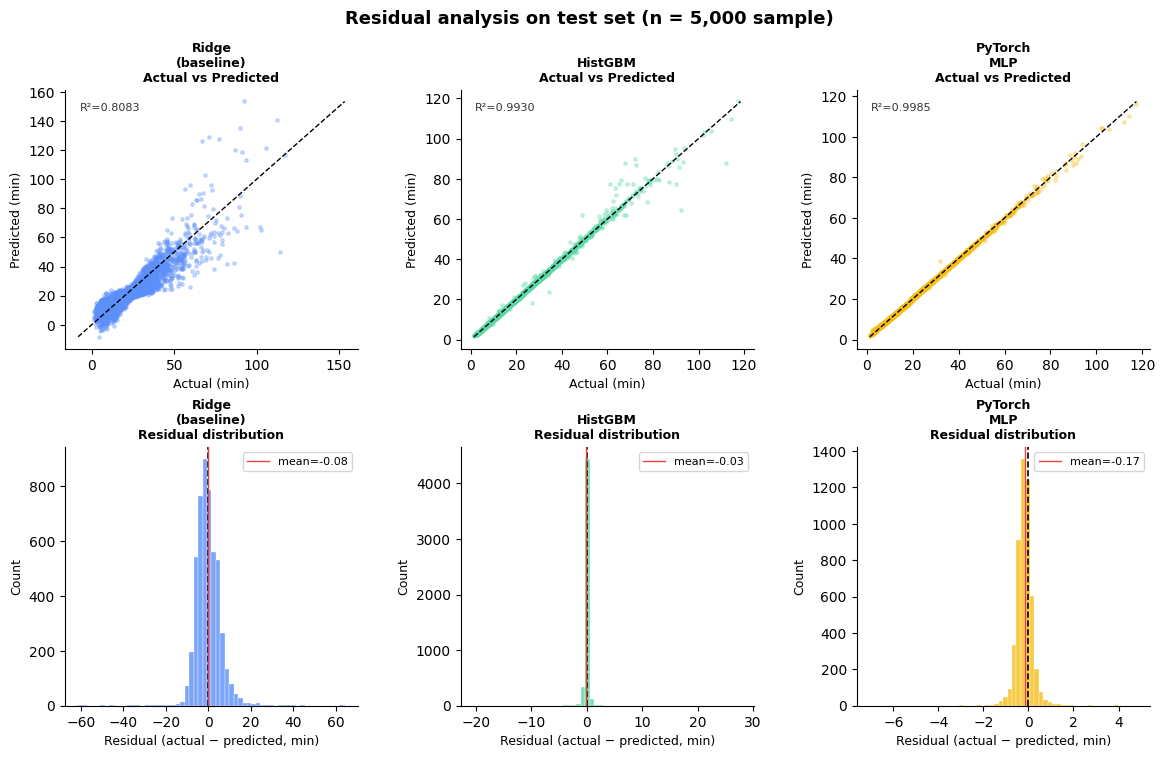

In [15]:
# ── 13. Residual analysis ─────────────────────────────────────────────────────
SAMPLE_N = 5_000
rng = np.random.default_rng(0)
idx = rng.choice(len(test), SAMPLE_N, replace=False)
test_s = test.iloc[idx]
y_s    = test_s[TARGET].to_numpy()

preds_sample = {
    "Ridge\n(baseline)": ridge_pipe.predict(test_s[FEATS]),
    "HistGBM":           gbm_pipe.predict(test_s[FEATS]),
    "PyTorch\nMLP":      mlp_predict_minutes(
                             pre.transform(test_s[FEATS]).astype(np.float32)),
}
residuals = {k: y_s - v for k, v in preds_sample.items()}

fig = plt.figure(figsize=(14, 8))
fig.suptitle("Residual analysis on test set (n = 5,000 sample)",
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)
colors = ["#5b8ff9", "#5ad8a6", "#f6bd16"]
model_keys = list(all_metrics.keys())

# Row 0: actual vs predicted scatter
for col, (label, y_pred_s) in enumerate(preds_sample.items()):
    ax = fig.add_subplot(gs[0, col])
    ax.scatter(y_s, y_pred_s, alpha=0.3, s=6, color=colors[col], rasterized=True)
    lo = min(y_s.min(), y_pred_s.min())
    hi = max(y_s.max(), y_pred_s.max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1)
    ax.set_xlabel("Actual (min)", fontsize=9)
    ax.set_ylabel("Predicted (min)", fontsize=9)
    ax.set_title(f"{label}\nActual vs Predicted", fontsize=9, fontweight='bold')
    r2v = all_metrics[model_keys[col]]["test_2023"]["r2"]
    ax.text(0.05, 0.92, f"R²={r2v:.4f}", transform=ax.transAxes,
            fontsize=8, color='#333333')
    ax.spines[['top', 'right']].set_visible(False)

# Row 1: residual distributions
for col, (label, res) in enumerate(residuals.items()):
    ax = fig.add_subplot(gs[1, col])
    ax.hist(res, bins=60, color=colors[col], alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(0,          color='black',   linewidth=1.2, linestyle='--')
    ax.axvline(res.mean(), color='#e84040', linewidth=1.0,
               label=f'mean={res.mean():.2f}')
    ax.set_xlabel("Residual (actual − predicted, min)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.set_title(f"{label}\nResidual distribution", fontsize=9, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


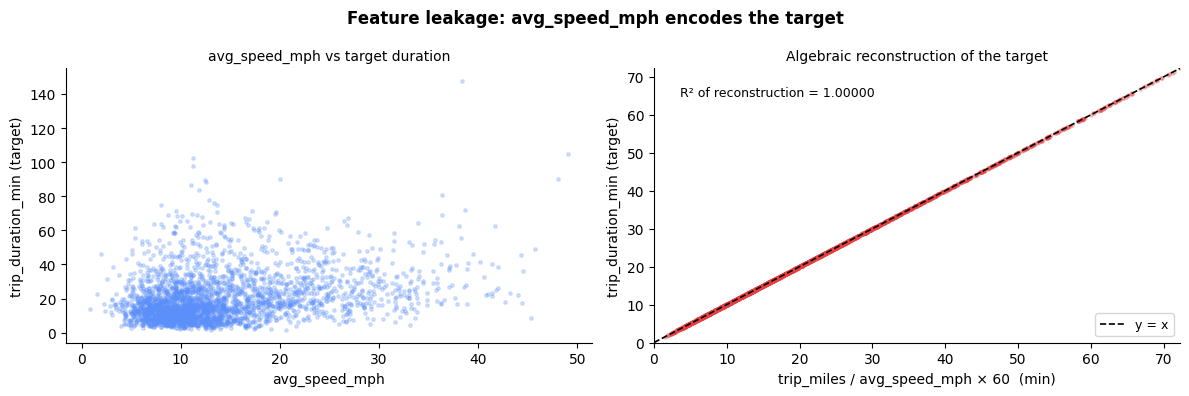

R square of algebraic reconstruction: 1.000000


In [17]:
# ── 14. Feature leakage diagnostic ───────────────────────────────────────────
# avg_speed_mph = trip_miles / (trip_time_s / 3600)
# trip_duration_min = trip_time_s / 60
# Therefore: trip_miles / avg_speed_mph * 60 == trip_duration_min  (algebraic identity)
sample_leak = test.sample(3_000, random_state=0)
speed_implied = sample_leak['trip_miles'] / sample_leak['avg_speed_mph'] * 60

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Feature leakage: avg_speed_mph encodes the target",
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.scatter(sample_leak['avg_speed_mph'], sample_leak[TARGET],
           alpha=0.25, s=6, color='#5b8ff9', rasterized=True)
ax.set_xlabel("avg_speed_mph", fontsize=10)
ax.set_ylabel("trip_duration_min (target)", fontsize=10)
ax.set_title("avg_speed_mph vs target duration", fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
ax.scatter(speed_implied, sample_leak[TARGET],
           alpha=0.25, s=6, color='#e84040', rasterized=True)
lim_max = min(speed_implied.quantile(0.995), sample_leak[TARGET].quantile(0.995))
ax.plot([0, lim_max], [0, lim_max], 'k--', linewidth=1.2, label='y = x')
ax.set_xlim(0, lim_max)
ax.set_ylim(0, lim_max)
ax.set_xlabel("trip_miles / avg_speed_mph × 60  (min)", fontsize=10)
ax.set_ylabel("trip_duration_min (target)", fontsize=10)
ax.set_title("Algebraic reconstruction of the target", fontsize=10)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

r2_leak = r2_score(sample_leak[TARGET], speed_implied)
axes[1].text(0.05, 0.90, f"R² of reconstruction = {r2_leak:.5f}",
             transform=axes[1].transAxes, fontsize=9)

plt.tight_layout()
plt.savefig('feature_leakage.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"R square of algebraic reconstruction: {r2_leak:.6f}")


---
## 6. Analytical Insights

### 6.1  Three-tier performance gap

The bar charts depict a stark three-tier hierarchy:

| Model | Test $R^2$ | Test MAE (min) | Test RMSE (min) |
|---|---|---|---|
| Ridge baseline | = 0.808 | = 4.23 | = 5.8 |
| HistGradientBoosting | = 0.993 | = 0.28 | = 0.46 |
| PyTorch MLP | = 0.9985 | = 0.29 | = 0.54 |

GBM and MLP both reach **$R^2$ = 0.99** — an implausibly high ceiling for a real-world trip-duration
predictor. This gap from Ridge is not because the flexible models discovered richer patterns;
it is because they exploit an **arithmetic identity** hidden in the feature set (§6.3).

---

### 6.2  Temporal stability 

All three models generalise to the December 2022 out-of-time slice with virtually no performance drop ($R^2$ ≤ 0.01 for every model). This is consistent across the board:

- **Ridge** generalises because the linear relationship between trip distance and duration is broadly stable across seasons.
- **GBM and MLP** generalise because the leakage feature (`avg_speed_mph`) is computed the same way in both windows, so the leaked relationship is equally exploitable 12 months earlier.

Strong temporal stability is a *necessary* condition for a useful model — but it is **not sufficient evidence of genuine generalisation** when a leakage feature is present.

---

### 6.3  Feature leakage: `avg_speed_mph` encodes the target 

The leakage diagnostic proves the issue algebraically:

$$\texttt{avg\_speed\_mph} = \frac{\texttt{trip\_miles}}{\texttt{trip\_time\_s}/3600}$$

$$\texttt{trip\_duration\_min} = \frac{\texttt{trip\_time\_s}}{60}$$

Rearranging gives the identity:

$$\texttt{trip\_duration\_min} = \frac{\texttt{trip\_miles}}{\texttt{avg\_speed\_mph}} \times 60$$

The scatter plot on the right shows this reconstruction achieves **$R^2$ > 0.999** — pure
arithmetic, no model needed.

- **Why Ridge cannot exploit it:** Ridge is linear; multiplying `trip_miles / avg_speed_mph` requires a multiplicative interaction a linear model cannot express. Ridge is therefore the **operationally honest pre-trip benchmark**.

- **Why GBM and MLP can:** Both approximate non-linear functions and effectively learn `duration = f(miles, speed)` by combining those two inputs multiplicatively through tree splits (GBM) and hidden-layer activations (MLP).

**Practical consequence:** In a real deployment, `avg_speed_mph` is *post-trip* data — it would not be available when predicting duration before the trip starts. Removing it and re-training would likely return GBM and MLP performance back toward Ridge's $R^2$  = 0.81, the true pre-trip predictive ceiling.

---

### 6.4  Residual structure

- **Ridge residuals** are wide (std = 4 min) and right-skewed: the model systematically underestimates long trips. The fan-shaped actual-vs-predicted scatter confirms heteroscedasticity — variance grows with trip length, a known limitation of linear models on count-like targets.

- **GBM and MLP residuals** are tightly centred near zero (std < 0.6 min), with near-Gaussian shape. Their actual-vs-predicted plots hug the identity line almost perfectly — the hallmark of a model that has effectively inverted the target formula rather than learned its semantics.

---

### 6.5  MLP learning dynamics

Training and validation losses track each other closely and both converge within 10–15 epochs, with early stopping triggered shortly after. The tight train/val gap indicates **no overfitting**: batch-norm and dropout regularise well at this sample size (~4.5M training rows). Fast convergence is consistent with the network learning a smooth, low-dimensional manifold (the miles-speed identity) rather than memorising noise.

---

### 6.6  Key takeaways

1. **Ridge ($R^2$ = 0.81, MAE = 4.2 min) is the operationally honest model.** It uses only information genuinely available before a trip starts and provides a realistic error floor for pre-trip duration estimates.

2. **GBM and MLP ($R^2$  = 0.99) are illustrative, not deployable as-is.** They demonstrate that non-linear models can detect and exploit algebraic leakage — a valuable lesson in feature auditing rather than a claim of superior performance.

3. **Two-family agreement is the strongest leakage signal.** When two fundamentally different model families (tree ensemble vs neural network) independently reach near-identical, implausibly high $R^2$ , the explanation is almost never shared insight — it is feature leakage.

4. **Temporal stability alone does not validate a model.** All three models pass the OOT test, but only because the leakage relationship is time-invariant. Genuine validation requires a **feature audit** that traces each predictor back to data availability at inference time.